In [ ]:
import pandas as pd
import nltk
import spacy
from spacy import displacy
NER = spacy.load("en_core_web_md")
#nltk.download('all')

from nltk import tokenize



In [45]:
df = pd.read_csv('../annotations/relevant_articles.csv')

In [70]:
articles = list(df['content'][:100])
titles = list(df['title'][:100])


In [71]:
r = []
for title, article in zip(titles, articles):
    sentences = tokenize.sent_tokenize(article)
    for i, sentence in enumerate(sentences):
        doc = NER(sentence)
        for entity in doc.ents:
            r.append({
                'title': title,
                "entity": entity.text,
                "label": entity.label_
            })

<Axes: xlabel='entity'>

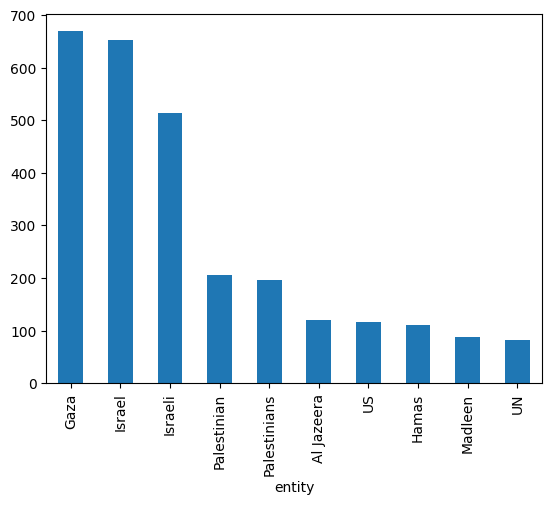

In [75]:
import json
pd.DataFrame(r).set_index('title')['entity'].value_counts().head(10).plot(kind='bar')